In [25]:
from matplotlib import pyplot as plt
import numpy as np
#import nch2369_23 as ns
g = 9.81 # m/s2

#### Parámetros de entrada

In [26]:
T_H = np.linspace(0, 5, 501)
cat = "cat2"
suelo = "C"
zona_sismica = 3
R = 3
xi = 0.03


#### Clasificación de estructuras y equipos según su importancia.

In [27]:
def coeficiente_importancia(cat="cat3"):
    cats = { "cat1": 0.8, "cat2": 1.0, "cat3": 1.2, "cat4":1.2}
    I = cats[cat]
    return I
I = coeficiente_importancia(cat)

#### Parámetros relativos al tipo de suelo:

In [28]:
def obtener_parametros(suelo):
    parametros_suelo = {
    "A": {"S": 0.90, "T_0": 0.15, "p": 1.85, "T1": 0.15},
    "B": {"S": 1.00, "T_0": 0.30, "p": 1.60, "T1": 0.27},
    "C": {"S": 1.05, "T_0": 0.40, "p": 1.50, "T1": 0.35},
    "D": {"S": 1.20, "T_0": 0.75, "p": 1.00, "T1": 0.52},
    "E": None  # Indica que se requiere espectro de sitio
}
    if suelo in parametros_suelo:
        return parametros_suelo[suelo]
    else:
        raise ValueError("El tipo de suelo no es válido. Debe ser A, B, C, D o E.")
    
S = obtener_parametros(suelo)["S"]
T_0 = obtener_parametros(suelo)["T_0"]
p = obtener_parametros(suelo)["p"]
T1 = obtener_parametros(suelo)["T1"]

#### 5.4. Espectros normativos
$A_0$ $=$ aceleración efectiva máxima del suelo

In [29]:
def aceleracion_efectiva(zona_sismica = 3):
    A0 = {1: 0.2, 2: 0.3, 3: 0.4}
    return A0[zona_sismica]

A_0 = aceleracion_efectiva(zona_sismica)

#### 5.4.2. Espectro de Referencia
Se define el siguiente espectro de referencia para la dirección horizontal y vertical:

In [30]:
S_aH_TH = np.zeros(len(T_H))
for i in range(len(T_H)):
    S_aH_TH[i] = 1.4 * S * A_0 * ((1 + 4.5 * (T_H[i] / T_0) ** p) / (1 + (T_H[i] / T_0) ** 3))
    # S_aV_TV = S * A_0 * ((1 + 4.5 * (T_V[i] / T_0) ** p) / (1 + (1.7 * T_V[i] / T_0) ** 3))

#### 5.4.1. Espectro de diseño
Se definen los siguientes espectros de diseño para las direcciones horizontal y vertical:

In [31]:
S_a_TH = 0.7 * I * S_aH_TH/R * (0.05/xi)**0.4
# S_a_TV = 0.7 * I * S_aV_TV/R * (0.05/xi)**0.4

#### Coeficiente sísmico adoptado:
$C_{h}=max(S_{a_{T_{H}}})$

In [32]:
C_h = max(S_a_TH)

#### 5.8. Equipos rígidos apoyados en el suelo
El diseñó sísmico de equipos rígidos apoyados en el suelo considera el siguiente factor $K_p$ y aceleración horizontal:

In [33]:
K_p = 1.0
a_k = 1.2 * S * A_0 * I


##### 7.2.2. Equipo no modelado salvo para su masa. Coeficiente sísmico uando no se ha realizado un análisis del edificio:
$C_{p.h}=\frac{a_{k}R_{1}K_{p}}{gR_{p}}$

In [34]:
# C_ph = a_k * R_1 * K_p / (g * R_p)

#### 5.12. Esfuerzo de corte basal mínimo
##### 5.12.1. Coeficiente sísmico mínimo:

In [35]:
C_min = ( 2.75 *I *S *A_0 ) / ( (R+1) ) * (0.05/xi)**0.4

#### Coeficiente sísmico máximo:

In [36]:
C_max = max(S_a_TH)

##### Factor de modificación de la respuesta estructural corregido por el requerimiento de corte basal mínimo

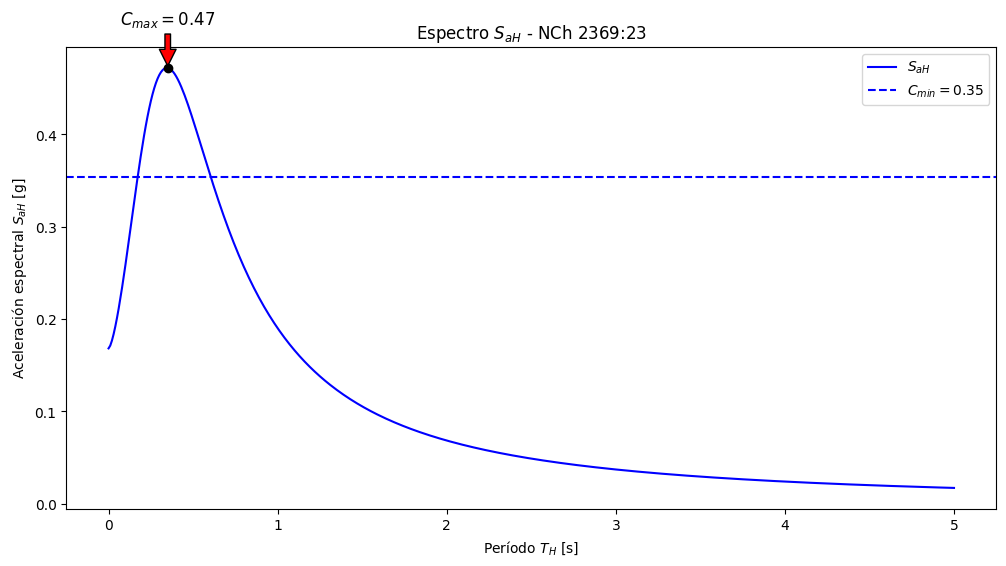

In [37]:
# Encontrar el índice donde se alcanza C_max
idx_max = np.argmax(S_a_TH)
x_max = T_H[idx_max]
y_max = S_a_TH[idx_max]

plt.figure(figsize=(12, 6)) 
plt.plot(T_H, S_a_TH, label=r'$S_{aH}$', color='blue')
plt.axhline(y=C_min, color='b', linestyle='--', label=rf'$C_{{min}} = {C_min:.2f}$')

# Anotación de C_max con subíndice
plt.scatter(x_max, y_max, color='black', zorder=5)
plt.annotate(rf'$C_{{max}} = {C_max:.2f}$',
            xy=(x_max, y_max),
            xytext=(x_max, y_max + 0.1 * C_max),
            arrowprops=dict(facecolor='red', shrink=0.05),
            horizontalalignment='center', fontsize=12, color='black')
plt.xlabel(r'Período $T_H$ [s]')
plt.ylabel(r'Aceleración espectral $S_{aH}$ [g]')
plt.title(r'Espectro $S_{aH}$ - NCh 2369:23')

plt.legend()

#### 5.7 Acción Sísmica Vertical
$F_v$ $=$ $C_v P$  
$C_v$ $=$ $1.18 I S A_0/g$

In [38]:
C_v = 1.18 * I * S * A_0
print(f"C_v: {C_v:.2f}")

C_v: 0.50
